## Path configuration

In [1]:
from pathlib import Path
import os

PROJECT_NAME = "MALDIAlign"

cwd = Path().resolve()

# Walk upwards until we find the project folder
target = None
for parent in [cwd] + list(cwd.parents):
    if parent.name == PROJECT_NAME:
        target = parent
        break

# If the project folder is found and we are not already there, then change cwd
if target is not None and target != cwd:
    os.chdir(target)

print("Working directory:", os.getcwd())

Working directory: /export/usuarios01/agnavarr/MALDIAlign


## Imports

In [2]:
import pickle
import numpy as np
import pandas as pd

# utils
from src.config.loader import *
from src.data.datasets import *
from src.data.preprocessing import *
from src.evaluation.metrics import *
from src.visualization.viz import *

# tools
from sklearn.model_selection import train_test_split

# models
from sklearn.ensemble import RandomForestClassifier

## Data loading

In [ ]:
## Data loading
cfg = load_config()

driams_dict  = load_driams(cfg["data"]["DRIAMS_REDUCED_PKL"])
marisma_dict = load_marisma(cfg["data"]["MARISMa_REDUCED_PKL"])
msumg_dict   = load_msumg(cfg["data"]["MSUMG_PKL"])
rki_dict     = load_rki(cfg["data"]["RKI_PKL"])

# Unpack
data_driams, label_driams, meta_driams = driams_dict["data"], driams_dict["label"], driams_dict["meta"]
data_marisma, label_marisma, meta_marisma = marisma_dict["data"], marisma_dict["label"], marisma_dict["meta"]
data_msumg, label_msumg, meta_msumg = msumg_dict["data"], msumg_dict["label"], msumg_dict["meta"]
data_rki, label_rki, meta_rki = rki_dict["data"], rki_dict["label"], rki_dict["meta"]

# Split DRIAMS by hospital
maskA = meta_driams["hospital"] == "DRIAMS_A"
maskB = meta_driams["hospital"] == "DRIAMS_B"
maskC = meta_driams["hospital"] == "DRIAMS_C"
maskD = meta_driams["hospital"] == "DRIAMS_D"

dataA, labelA, metaA = data_driams[maskA], label_driams[maskA], meta_driams[maskA]
dataB, labelB, metaB = data_driams[maskB], label_driams[maskB], meta_driams[maskB]
dataC, labelC, metaC = data_driams[maskC], label_driams[maskC], meta_driams[maskC]
dataD, labelD, metaD = data_driams[maskD], label_driams[maskD], meta_driams[maskD]

# Normalize
dataA = row_minmax_normalize(dataA)
dataB = row_minmax_normalize(dataB)
dataC = row_minmax_normalize(dataC)
dataD = row_minmax_normalize(dataD)
data_marisma = row_minmax_normalize(data_marisma)
data_msumg = row_minmax_normalize(data_msumg)
data_rki = row_minmax_normalize(data_rki)

# Build dataset used for VAE training to ensure correct index usage
data_list = [
    dataA,
    dataB,
    dataC,
    data_marisma,
    data_rki
]

label_list = [
    labelA,
    labelB,
    labelC,
    label_marisma,
    label_rki
]

meta_list = [
    metaA,
    metaB,
    metaC,
    meta_marisma,
    meta_rki
]

data_final = np.vstack(data_list)
label_final = np.concatenate(label_list)
meta_final = pd.concat(meta_list, ignore_index=True).reset_index(drop=True)

# Load splits
experiment_dir = Path("experiments/results/vae_multidecoder_prior/20260324_220105")

with open(experiment_dir / "data_splits.pkl", "rb") as f:
    splits = pickle.load(f)

# Build train tests
domains_train = {
    "A": (
        data_final[splits["splits_per_domain"]["DRIAMS_A"]["train_idx"]],
        label_final[splits["splits_per_domain"]["DRIAMS_A"]["train_idx"]],
    ),
    "B": (
        data_final[splits["splits_per_domain"]["DRIAMS_B"]["train_idx"]],
        label_final[splits["splits_per_domain"]["DRIAMS_B"]["train_idx"]],
    ),
    "C": (
        data_final[splits["splits_per_domain"]["DRIAMS_C"]["train_idx"]],
        label_final[splits["splits_per_domain"]["DRIAMS_C"]["train_idx"]],
    ),
    "MARISMA": (
        data_final[splits["splits_per_domain"]["MARISMA"]["train_idx"]],
        label_final[splits["splits_per_domain"]["MARISMA"]["train_idx"]],
    ),
    "RKI": (
        data_final[splits["splits_per_domain"]["RKI"]["train_idx"]],
        label_final[splits["splits_per_domain"]["RKI"]["train_idx"]],
    )
}

# Build test sets
test_sets = {
    "A": (
        data_final[splits["splits_per_domain"]["DRIAMS_A"]["test_idx"]],
        label_final[splits["splits_per_domain"]["DRIAMS_A"]["test_idx"]],
    ),
    "B": (
        data_final[splits["splits_per_domain"]["DRIAMS_B"]["test_idx"]],
        label_final[splits["splits_per_domain"]["DRIAMS_B"]["test_idx"]],
    ),
    "C": (
        data_final[splits["splits_per_domain"]["DRIAMS_C"]["test_idx"]],
        label_final[splits["splits_per_domain"]["DRIAMS_C"]["test_idx"]],
    ),
    "MARISMA": (
        data_final[splits["splits_per_domain"]["MARISMA"]["test_idx"]],
        label_final[splits["splits_per_domain"]["MARISMA"]["test_idx"]],
    ),
    "RKI": (
        data_final[splits["splits_per_domain"]["RKI"]["test_idx"]],
        label_final[splits["splits_per_domain"]["RKI"]["test_idx"]],
    ),

    # OOD
    "D (OOD)": (dataD, labelD),
    "MSUMG (OOD)": (data_msumg, label_msumg),
}

## Load VAE

In [22]:
import torch
from models.deep.MultiVAEPrior import MultiVAE_Bernoulli_SpeciesPrior_Extended

In [23]:
def load_model(model, path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model

def encode_latent(model, X, device, batch_size=256):
    Z = []
    X_tensor = torch.tensor(X, dtype=torch.float32)

    loader = torch.utils.data.DataLoader(X_tensor, batch_size=batch_size)

    with torch.no_grad():
        for x in loader:
            x = x.to(device)
            mu, _ = model.encoder(x)
            Z.append(mu.cpu().numpy())

    return np.vstack(Z)

In [24]:
# VAE entrenado SOLO en A+B+C+MARISMA+RKI (sin D ni MSUMG)
data_seen = np.vstack([dataA, dataB, dataC, data_marisma, data_rki])
label_seen = np.concatenate([labelA, labelB, labelC, label_marisma, label_rki])
vae = load_model(MultiVAE_Bernoulli_SpeciesPrior_Extended(input_dim=data_seen.shape[1], latent_dim=64, num_domains=5, n_species=len(np.unique(label_seen))), experiment_dir / "model.pth")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [27]:
# Seen domains
Z_final = encode_latent(vae, data_final, device)

# OOD
Z_D = encode_latent(vae, dataD, device)
Z_MSUMG = encode_latent(vae, data_msumg, device)

Latent encoding done.


In [28]:
domains_train_latent = {
    "A": (
        Z_final[splits["splits_per_domain"]["DRIAMS_A"]["train_idx"]],
        label_final[splits["splits_per_domain"]["DRIAMS_A"]["train_idx"]],
    ),
    "B": (
        Z_final[splits["splits_per_domain"]["DRIAMS_B"]["train_idx"]],
        label_final[splits["splits_per_domain"]["DRIAMS_B"]["train_idx"]],
    ),
    "C": (
        Z_final[splits["splits_per_domain"]["DRIAMS_C"]["train_idx"]],
        label_final[splits["splits_per_domain"]["DRIAMS_C"]["train_idx"]],
    ),
    "MARISMA": (
        Z_final[splits["splits_per_domain"]["MARISMA"]["train_idx"]],
        label_final[splits["splits_per_domain"]["MARISMA"]["train_idx"]],
    ),
    "RKI": (
        Z_final[splits["splits_per_domain"]["RKI"]["train_idx"]],
        label_final[splits["splits_per_domain"]["RKI"]["train_idx"]],
    ),

    "D (OOD train)": (Z_D, labelD),
    "MSUMG (OOD train)": (Z_MSUMG, label_msumg),
}

In [29]:
test_sets_latent = {
    "A": (
        Z_final[splits["splits_per_domain"]["DRIAMS_A"]["test_idx"]],
        label_final[splits["splits_per_domain"]["DRIAMS_A"]["test_idx"]],
    ),
    "B": (
        Z_final[splits["splits_per_domain"]["DRIAMS_B"]["test_idx"]],
        label_final[splits["splits_per_domain"]["DRIAMS_B"]["test_idx"]],
    ),
    "C": (
        Z_final[splits["splits_per_domain"]["DRIAMS_C"]["test_idx"]],
        label_final[splits["splits_per_domain"]["DRIAMS_C"]["test_idx"]],
    ),
    "MARISMA": (
        Z_final[splits["splits_per_domain"]["MARISMA"]["test_idx"]],
        label_final[splits["splits_per_domain"]["MARISMA"]["test_idx"]],
    ),
    "RKI": (
        Z_final[splits["splits_per_domain"]["RKI"]["test_idx"]],
        label_final[splits["splits_per_domain"]["RKI"]["test_idx"]],
    ),

    "D (OOD)": (Z_D, labelD),
    "MSUMG (OOD)": (Z_MSUMG, label_msumg),
}

## Cross-domain loop


TRAIN DOMAIN: A

------------------------------
A to A
------------------------------

===== Metrics =====
Domain: A-A (orig)
Balanced Accuracy: 0.9982
F1 Macro: 0.9986
Recall Macro: 0.9982
Specificity Macro: 0.9997



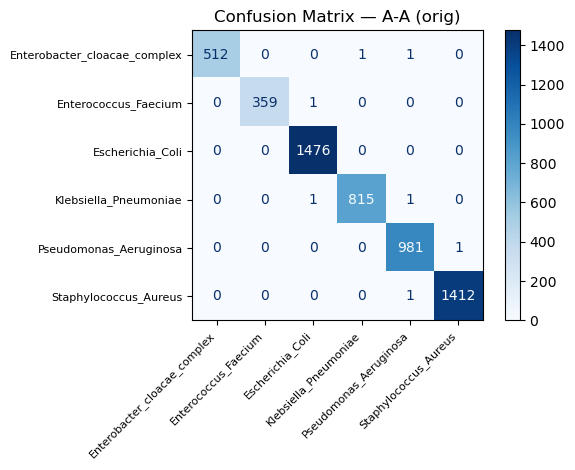


===== Metrics =====
Domain: A-A (latent)
Balanced Accuracy: 0.9982
F1 Macro: 0.9986
Recall Macro: 0.9982
Specificity Macro: 0.9997



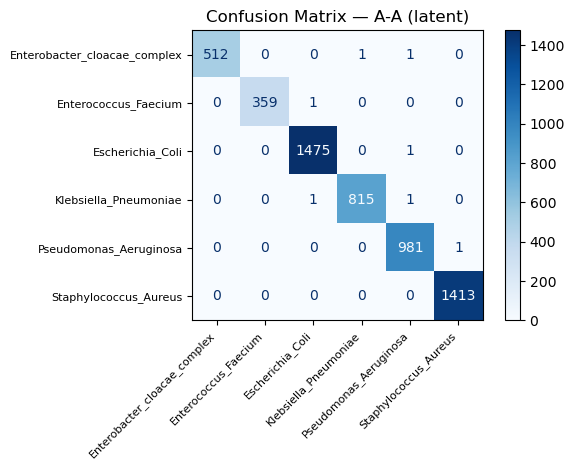


------------------------------
A to B
------------------------------

===== Metrics =====
Domain: A-B (orig)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



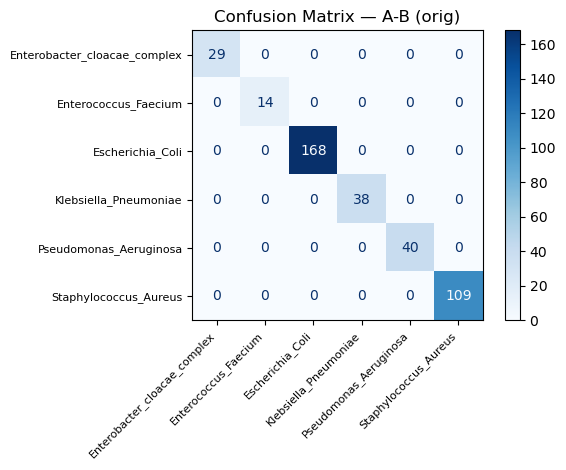


===== Metrics =====
Domain: A-B (latent)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



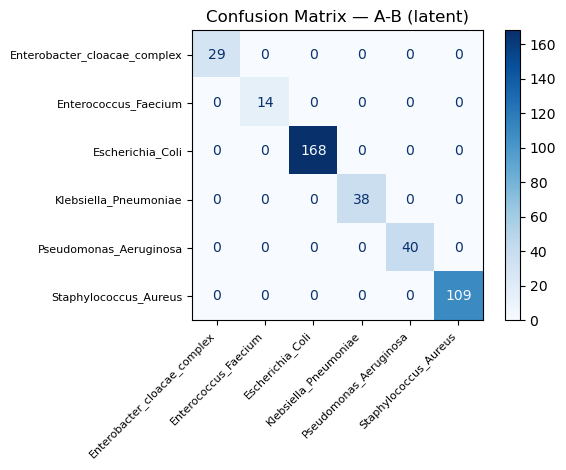


------------------------------
A to C
------------------------------

===== Metrics =====
Domain: A-C (orig)
Balanced Accuracy: 0.9991
F1 Macro: 0.9990
Recall Macro: 0.9991
Specificity Macro: 0.9996



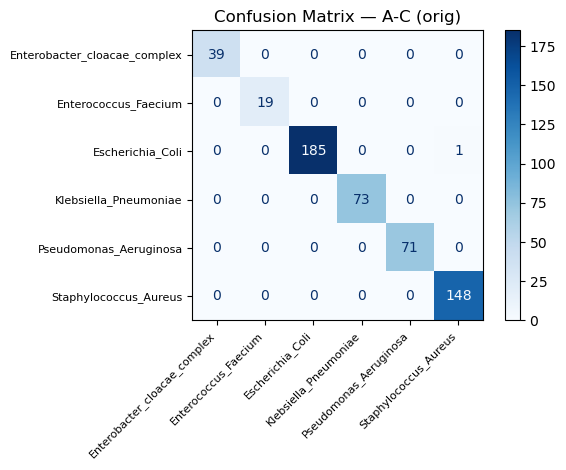


===== Metrics =====
Domain: A-C (latent)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



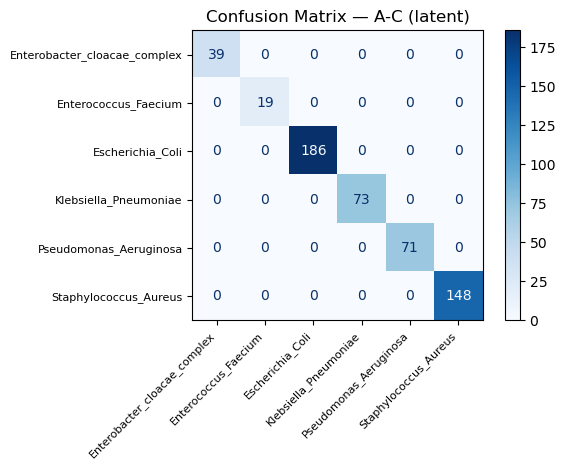


------------------------------
A to MARISMA
------------------------------

===== Metrics =====
Domain: A-MARISMA (orig)
Balanced Accuracy: 0.9881
F1 Macro: 0.9928
Recall Macro: 0.9881
Specificity Macro: 0.9994



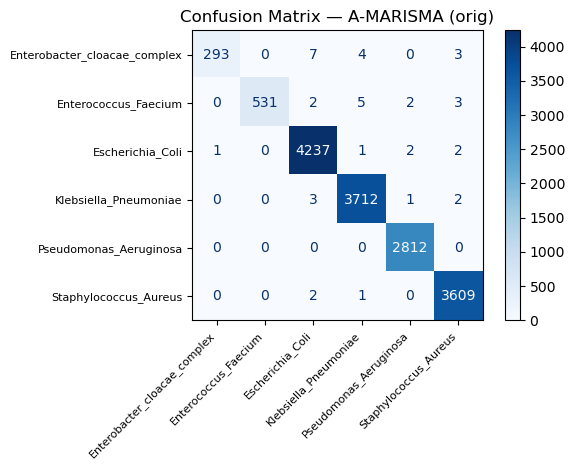


===== Metrics =====
Domain: A-MARISMA (latent)
Balanced Accuracy: 0.9941
F1 Macro: 0.9964
Recall Macro: 0.9941
Specificity Macro: 0.9996



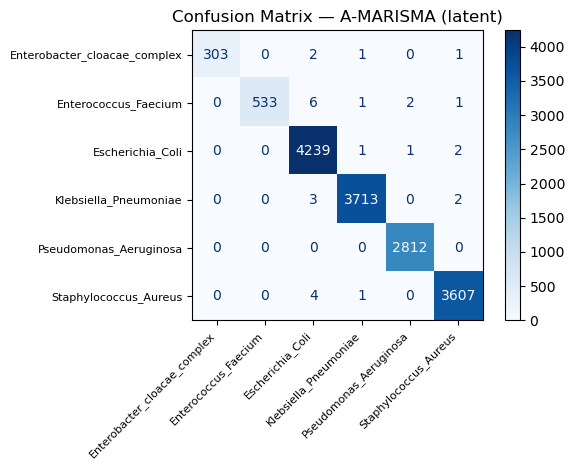


------------------------------
A to RKI
------------------------------

===== Metrics =====
Domain: A-RKI (orig)
Balanced Accuracy: 0.9977
F1 Macro: 0.9922
Recall Macro: 0.9977
Specificity Macro: 0.9988



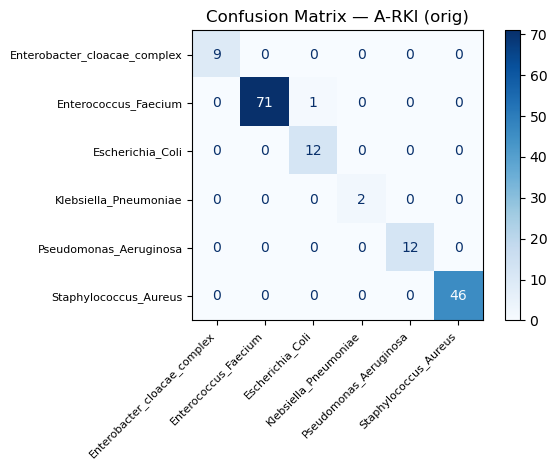


===== Metrics =====
Domain: A-RKI (latent)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



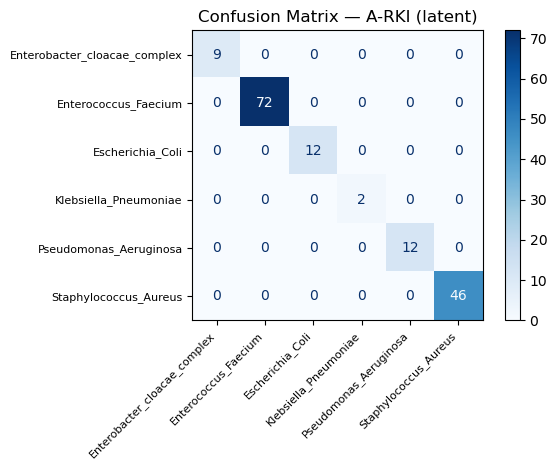


------------------------------
A to D (OOD)
------------------------------

===== Metrics =====
Domain: A-D (OOD) (orig)
Balanced Accuracy: 0.9176
F1 Macro: 0.8991
Recall Macro: 0.9176
Specificity Macro: 0.9796



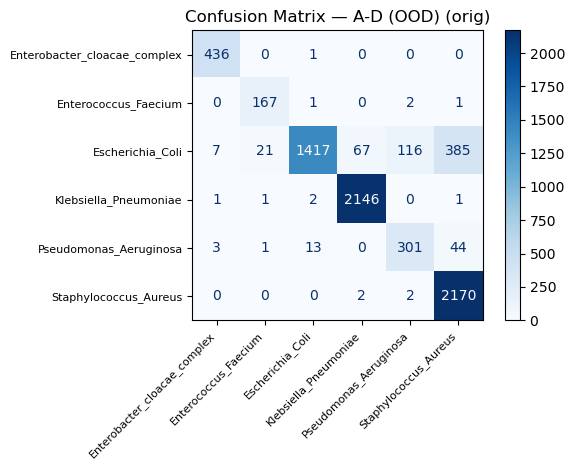


===== Metrics =====
Domain: A-D (OOD) (latent)
Balanced Accuracy: 0.9330
F1 Macro: 0.9447
Recall Macro: 0.9330
Specificity Macro: 0.9875



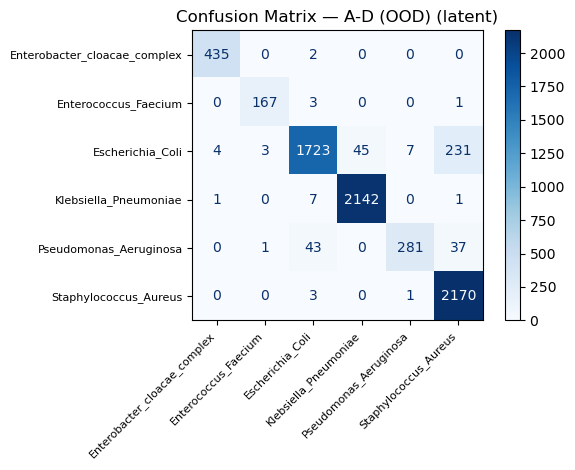


------------------------------
A to MSUMG (OOD)
------------------------------

===== Metrics =====
Domain: A-MSUMG (OOD) (orig)
Balanced Accuracy: 0.7088
F1 Macro: 0.7422
Recall Macro: 0.7088
Specificity Macro: 0.9651



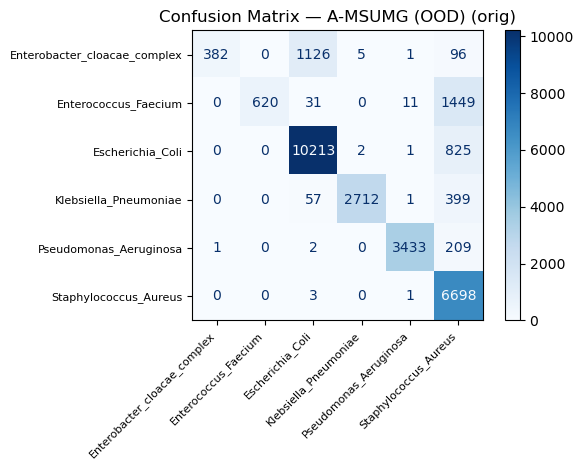


===== Metrics =====
Domain: A-MSUMG (OOD) (latent)
Balanced Accuracy: 0.8388
F1 Macro: 0.8782
Recall Macro: 0.8388
Specificity Macro: 0.9790



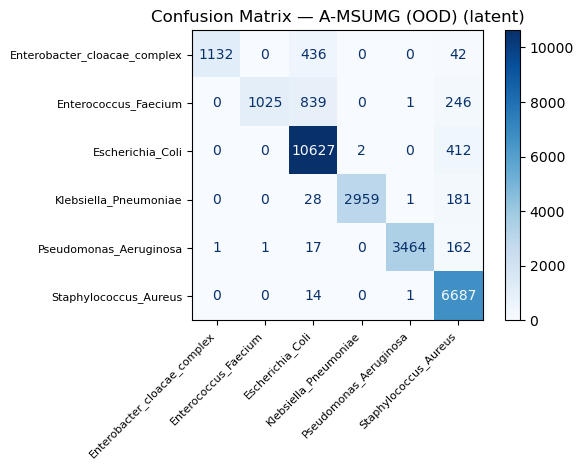


TRAIN DOMAIN: B

------------------------------
B to A
------------------------------

===== Metrics =====
Domain: B-A (orig)
Balanced Accuracy: 0.9944
F1 Macro: 0.9954
Recall Macro: 0.9944
Specificity Macro: 0.9989



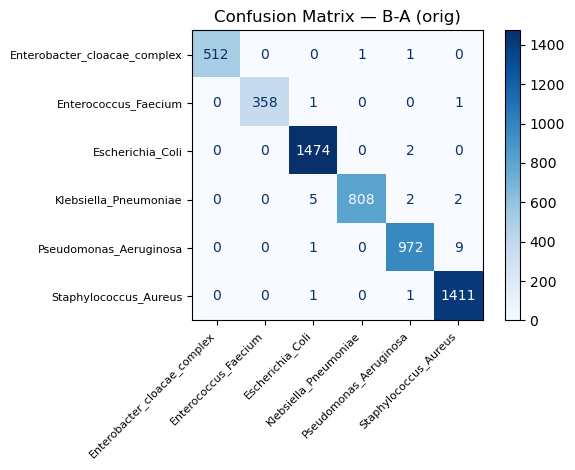


===== Metrics =====
Domain: B-A (latent)
Balanced Accuracy: 0.9985
F1 Macro: 0.9987
Recall Macro: 0.9985
Specificity Macro: 0.9997



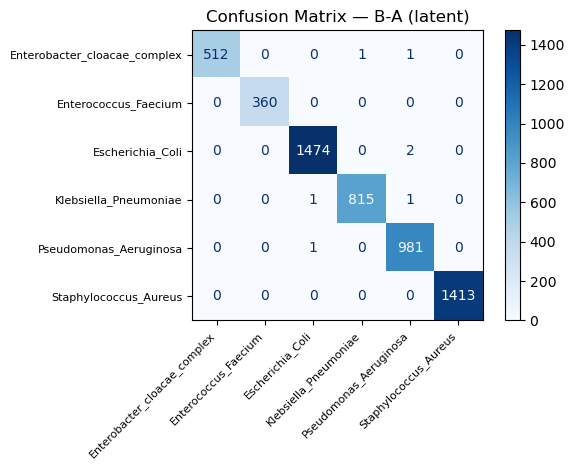


------------------------------
B to B
------------------------------

===== Metrics =====
Domain: B-B (orig)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



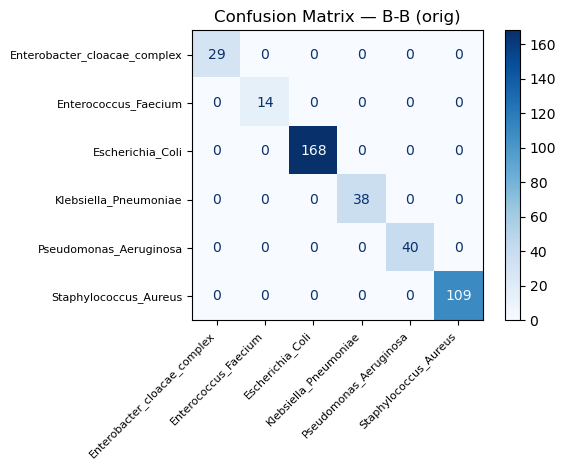


===== Metrics =====
Domain: B-B (latent)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



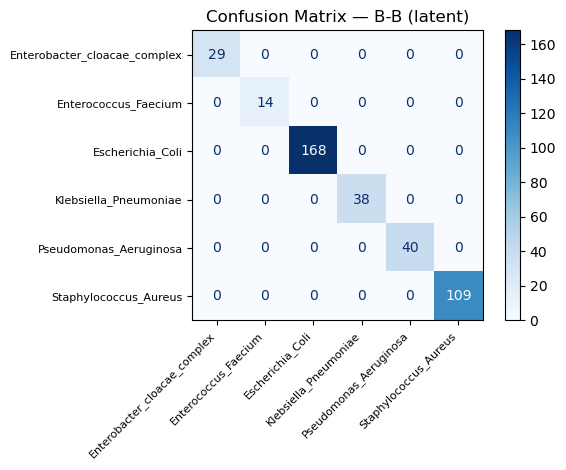


------------------------------
B to C
------------------------------

===== Metrics =====
Domain: B-C (orig)
Balanced Accuracy: 0.9991
F1 Macro: 0.9990
Recall Macro: 0.9991
Specificity Macro: 0.9996



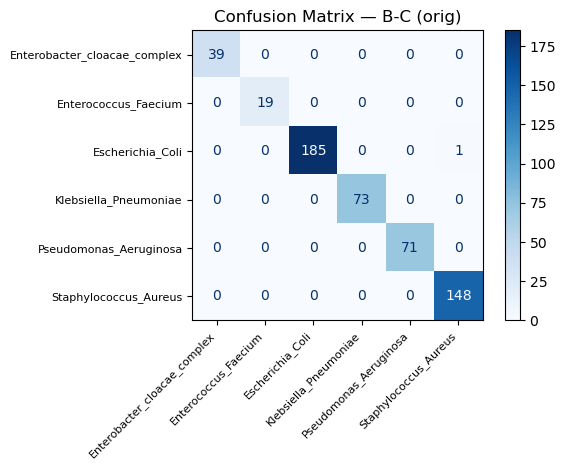


===== Metrics =====
Domain: B-C (latent)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



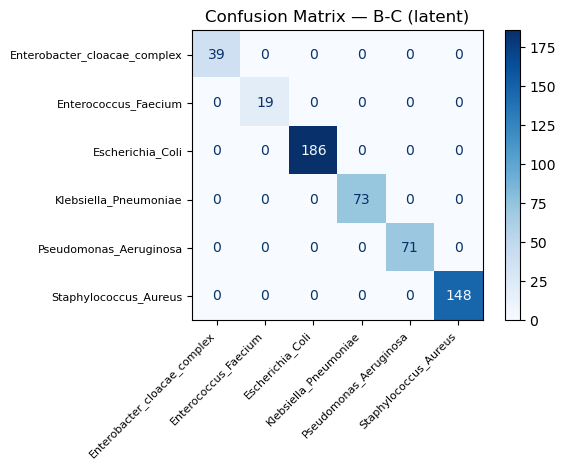


------------------------------
B to MARISMA
------------------------------

===== Metrics =====
Domain: B-MARISMA (orig)
Balanced Accuracy: 0.9833
F1 Macro: 0.9895
Recall Macro: 0.9833
Specificity Macro: 0.9989



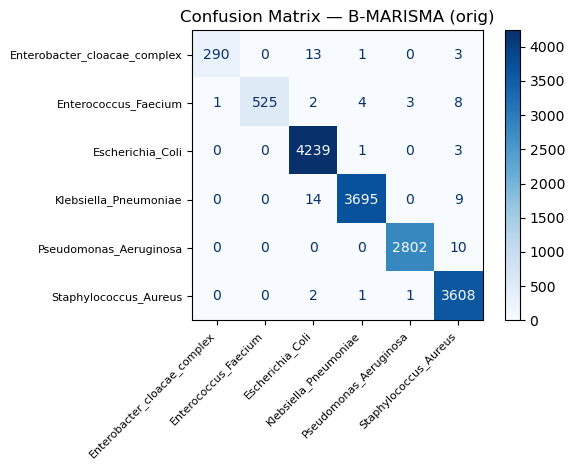


===== Metrics =====
Domain: B-MARISMA (latent)
Balanced Accuracy: 0.9954
F1 Macro: 0.9971
Recall Macro: 0.9954
Specificity Macro: 0.9997



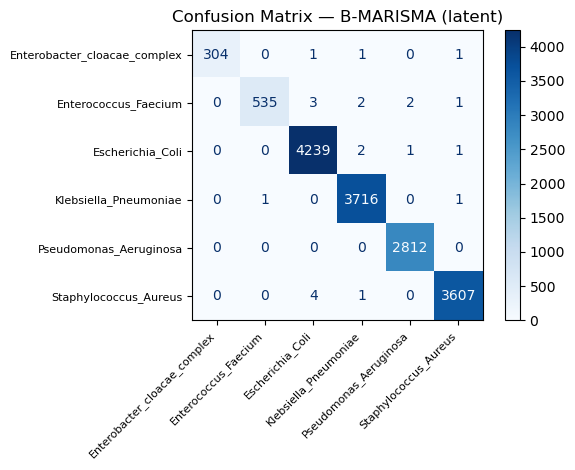


------------------------------
B to RKI
------------------------------

===== Metrics =====
Domain: B-RKI (orig)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



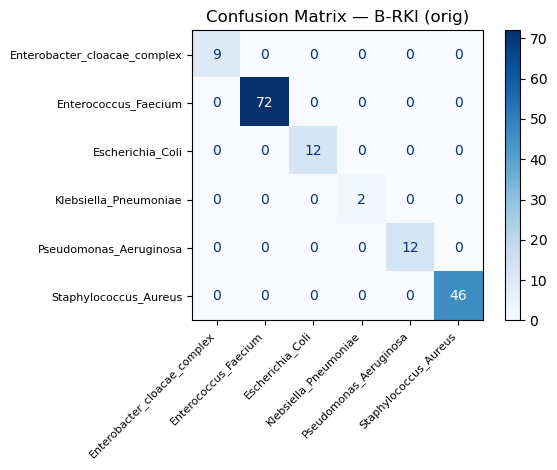


===== Metrics =====
Domain: B-RKI (latent)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



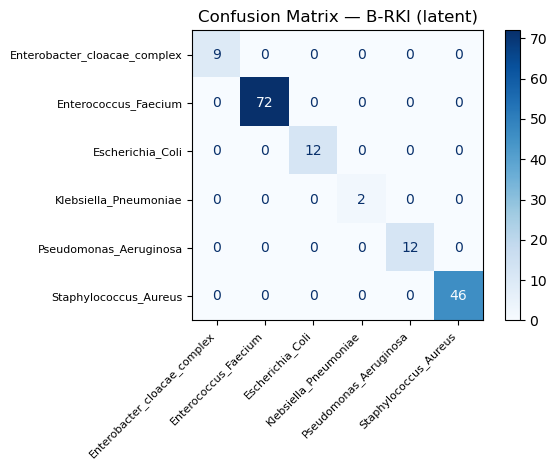


------------------------------
B to D (OOD)
------------------------------

===== Metrics =====
Domain: B-D (OOD) (orig)
Balanced Accuracy: 0.9027
F1 Macro: 0.9129
Recall Macro: 0.9027
Specificity Macro: 0.9758



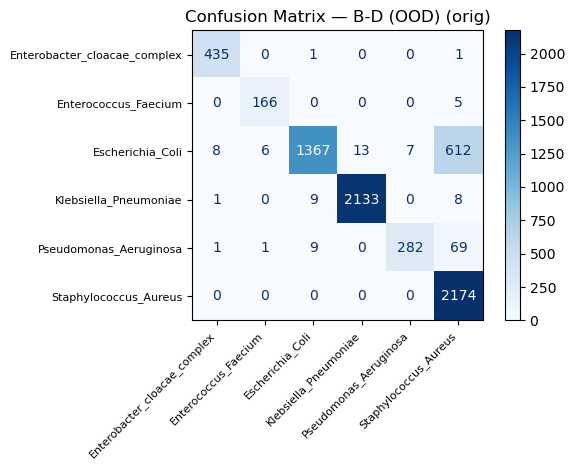


===== Metrics =====
Domain: B-D (OOD) (latent)
Balanced Accuracy: 0.9308
F1 Macro: 0.9273
Recall Macro: 0.9308
Specificity Macro: 0.9864



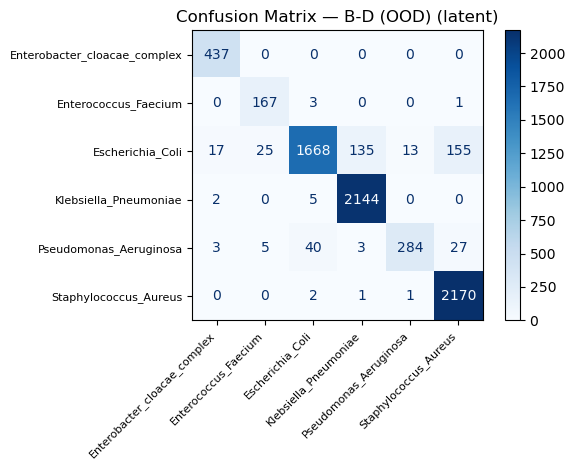


------------------------------
B to MSUMG (OOD)
------------------------------

===== Metrics =====
Domain: B-MSUMG (OOD) (orig)
Balanced Accuracy: 0.4756
F1 Macro: 0.5046
Recall Macro: 0.4756
Specificity Macro: 0.9260



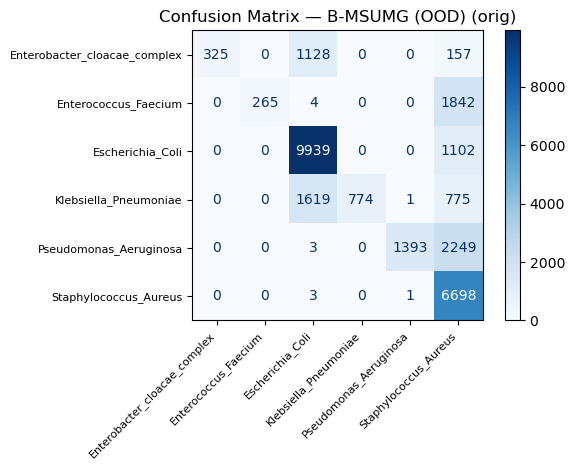


===== Metrics =====
Domain: B-MSUMG (OOD) (latent)
Balanced Accuracy: 0.9451
F1 Macro: 0.9643
Recall Macro: 0.9451
Specificity Macro: 0.9913



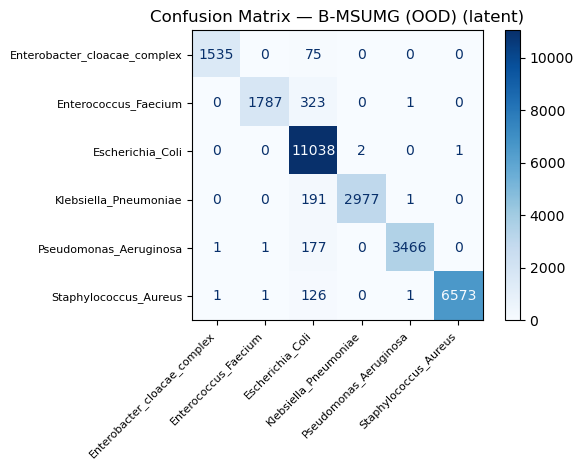


TRAIN DOMAIN: C

------------------------------
C to A
------------------------------

===== Metrics =====
Domain: C-A (orig)
Balanced Accuracy: 0.9958
F1 Macro: 0.9957
Recall Macro: 0.9958
Specificity Macro: 0.9993



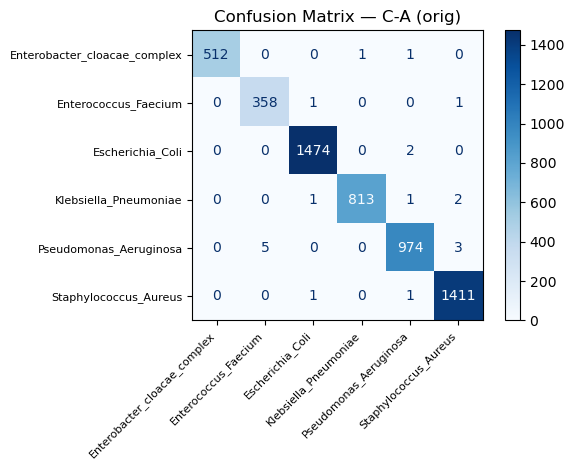


===== Metrics =====
Domain: C-A (latent)
Balanced Accuracy: 0.9983
F1 Macro: 0.9985
Recall Macro: 0.9983
Specificity Macro: 0.9997



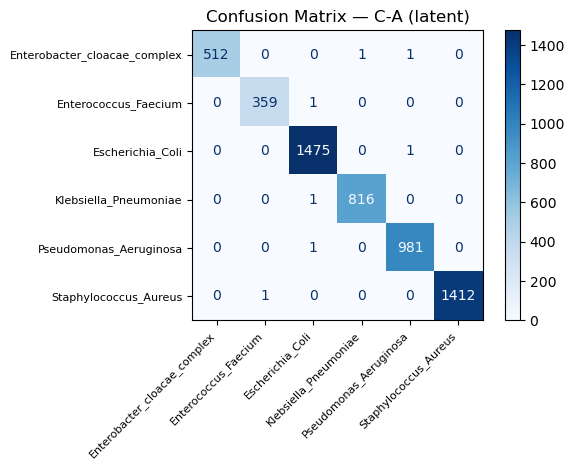


------------------------------
C to B
------------------------------

===== Metrics =====
Domain: C-B (orig)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



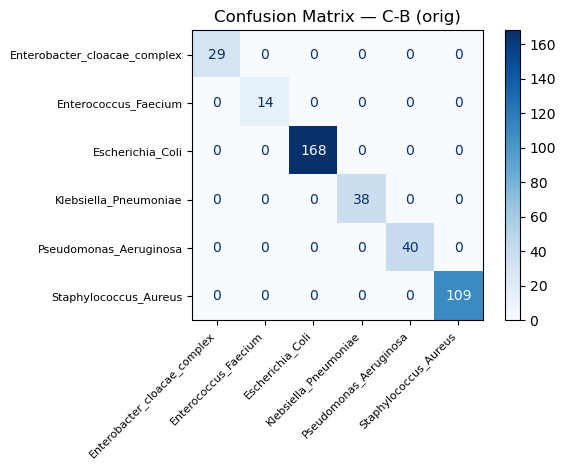


===== Metrics =====
Domain: C-B (latent)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



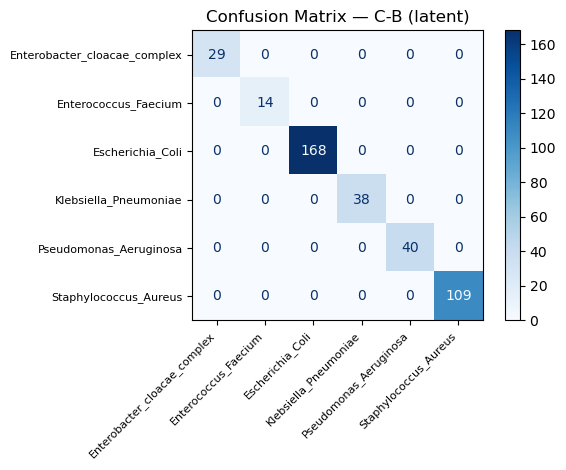


------------------------------
C to C
------------------------------

===== Metrics =====
Domain: C-C (orig)
Balanced Accuracy: 0.9957
F1 Macro: 0.9974
Recall Macro: 0.9957
Specificity Macro: 0.9995



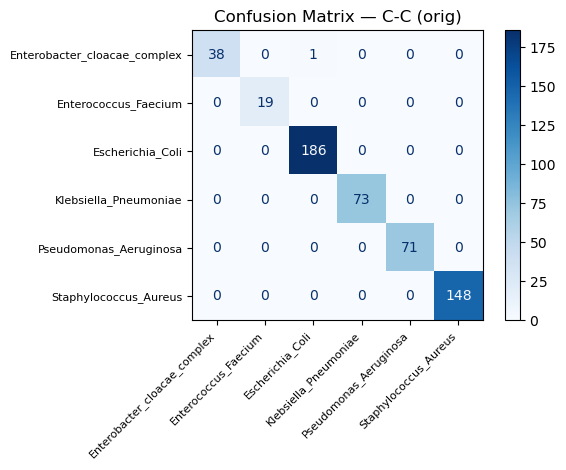


===== Metrics =====
Domain: C-C (latent)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



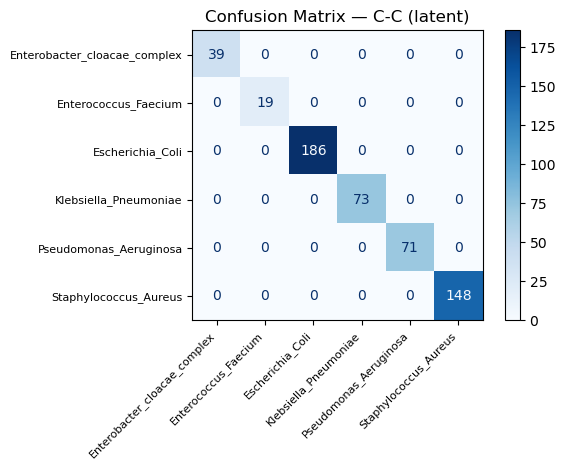


------------------------------
C to MARISMA
------------------------------

===== Metrics =====
Domain: C-MARISMA (orig)
Balanced Accuracy: 0.9714
F1 Macro: 0.9821
Recall Macro: 0.9714
Specificity Macro: 0.9985



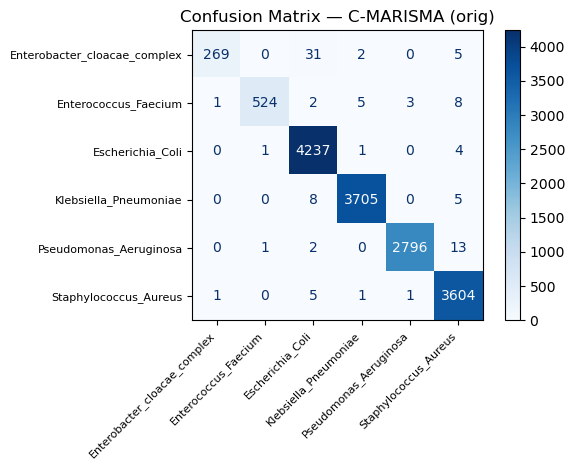


===== Metrics =====
Domain: C-MARISMA (latent)
Balanced Accuracy: 0.9953
F1 Macro: 0.9971
Recall Macro: 0.9953
Specificity Macro: 0.9996



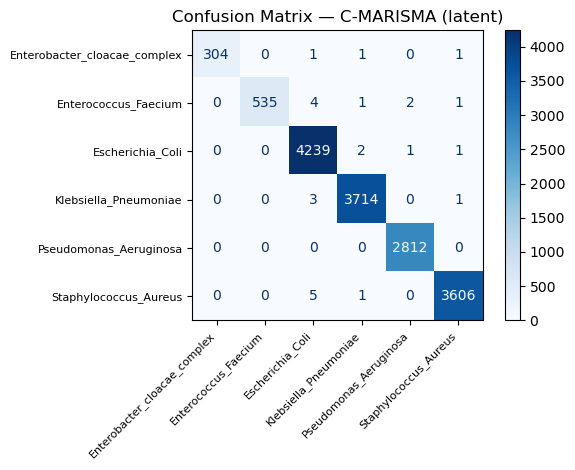


------------------------------
C to RKI
------------------------------

===== Metrics =====
Domain: C-RKI (orig)
Balanced Accuracy: 0.9977
F1 Macro: 0.9970
Recall Macro: 0.9977
Specificity Macro: 0.9984



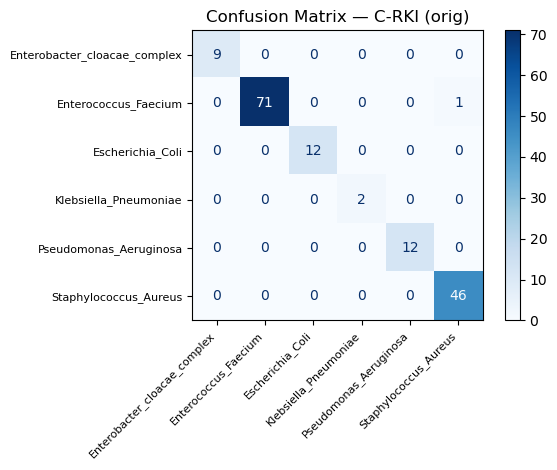


===== Metrics =====
Domain: C-RKI (latent)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



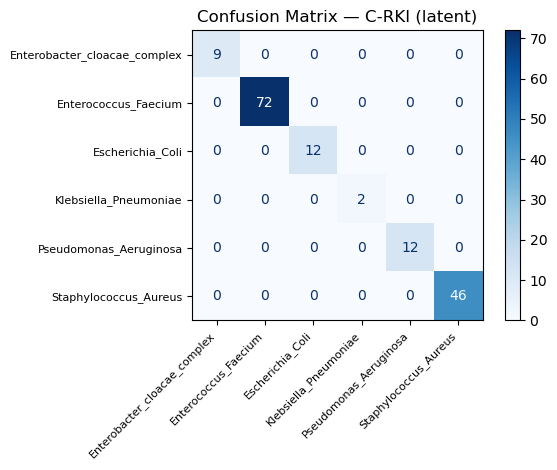


------------------------------
C to D (OOD)
------------------------------

===== Metrics =====
Domain: C-D (OOD) (orig)
Balanced Accuracy: 0.8994
F1 Macro: 0.8923
Recall Macro: 0.8994
Specificity Macro: 0.9760



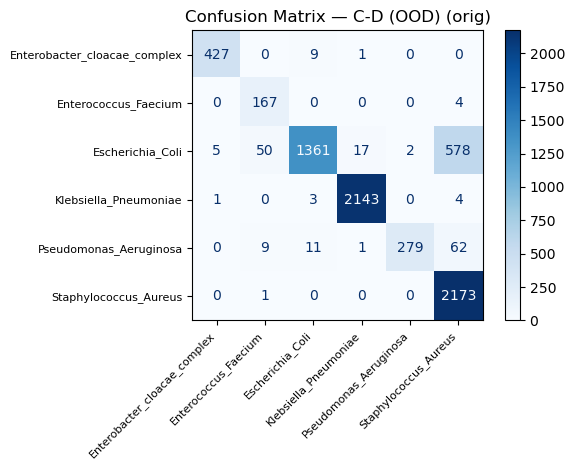


===== Metrics =====
Domain: C-D (OOD) (latent)
Balanced Accuracy: 0.9387
F1 Macro: 0.9446
Recall Macro: 0.9387
Specificity Macro: 0.9896



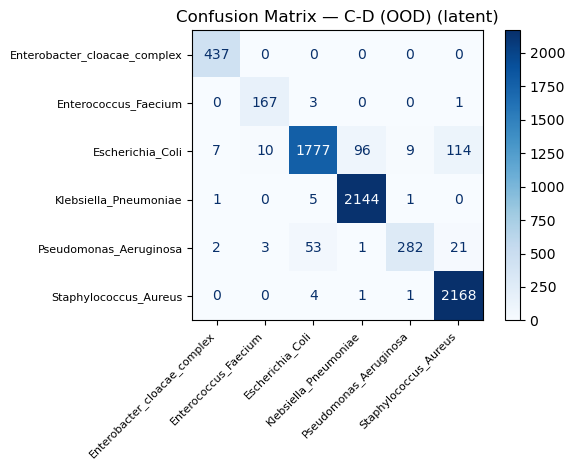


------------------------------
C to MSUMG (OOD)
------------------------------

===== Metrics =====
Domain: C-MSUMG (OOD) (orig)
Balanced Accuracy: 0.6348
F1 Macro: 0.6773
Recall Macro: 0.6348
Specificity Macro: 0.9480



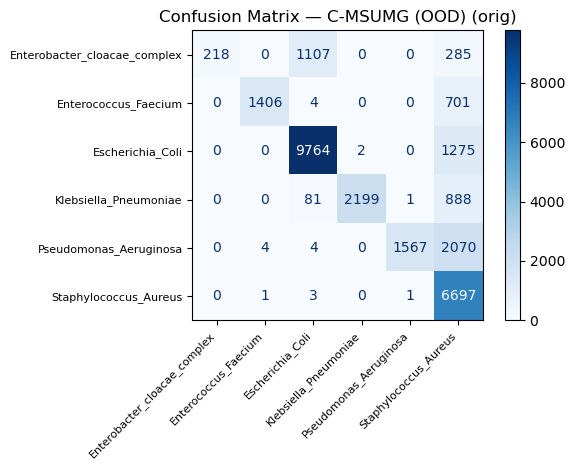


===== Metrics =====
Domain: C-MSUMG (OOD) (latent)
Balanced Accuracy: 0.9299
F1 Macro: 0.9545
Recall Macro: 0.9299
Specificity Macro: 0.9896



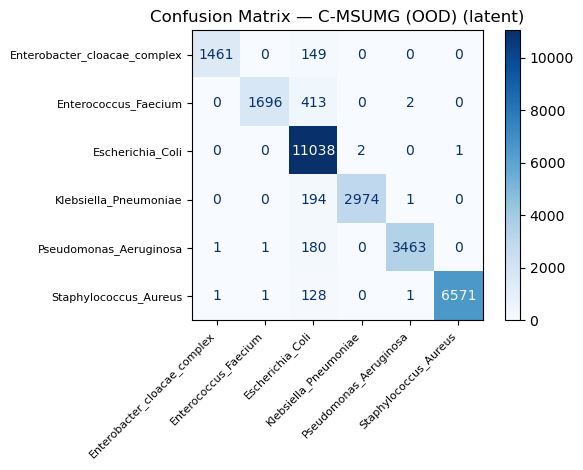


TRAIN DOMAIN: MARISMA

------------------------------
MARISMA to A
------------------------------

===== Metrics =====
Domain: MARISMA-A (orig)
Balanced Accuracy: 0.9968
F1 Macro: 0.9975
Recall Macro: 0.9968
Specificity Macro: 0.9995



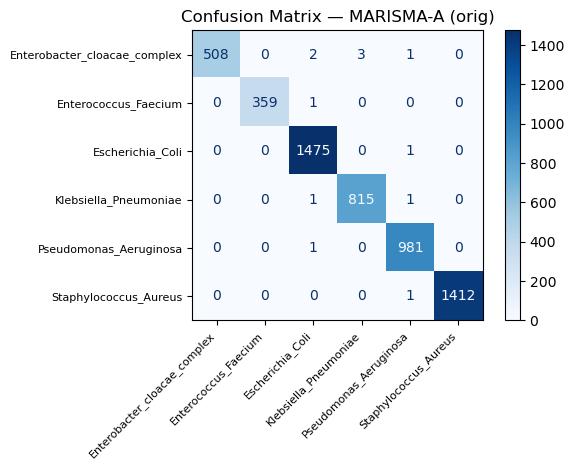


===== Metrics =====
Domain: MARISMA-A (latent)
Balanced Accuracy: 0.9989
F1 Macro: 0.9989
Recall Macro: 0.9989
Specificity Macro: 0.9998



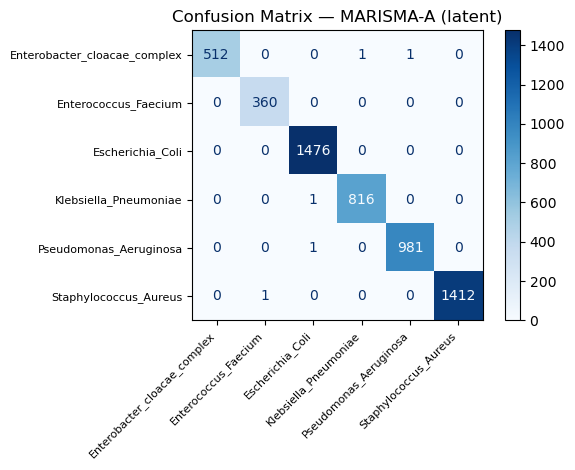


------------------------------
MARISMA to B
------------------------------

===== Metrics =====
Domain: MARISMA-B (orig)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



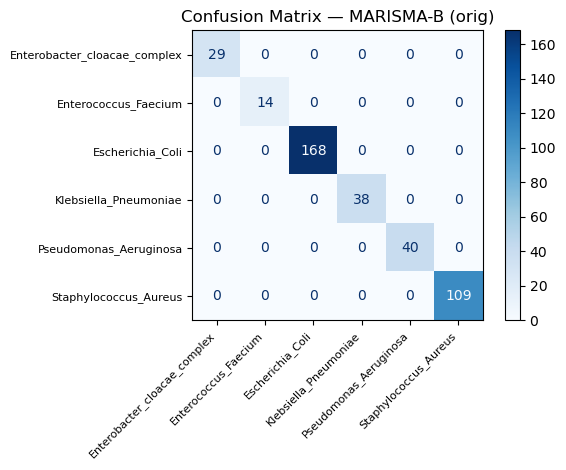


===== Metrics =====
Domain: MARISMA-B (latent)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



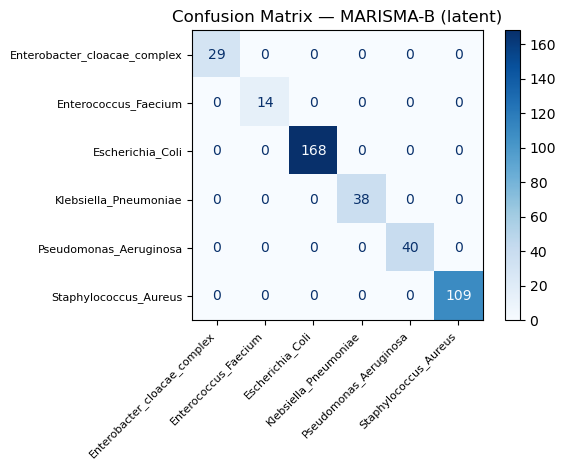


------------------------------
MARISMA to C
------------------------------

===== Metrics =====
Domain: MARISMA-C (orig)
Balanced Accuracy: 0.9991
F1 Macro: 0.9990
Recall Macro: 0.9991
Specificity Macro: 0.9996



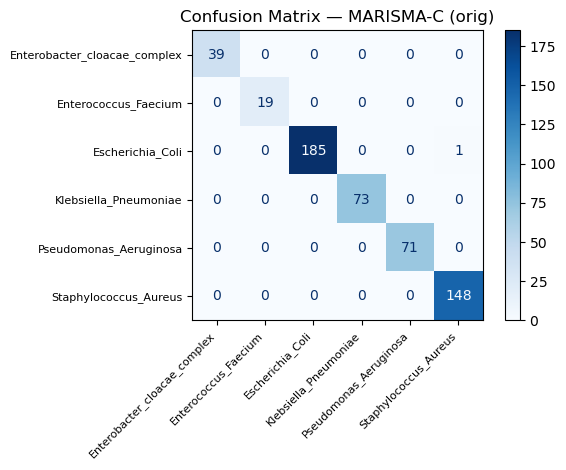


===== Metrics =====
Domain: MARISMA-C (latent)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



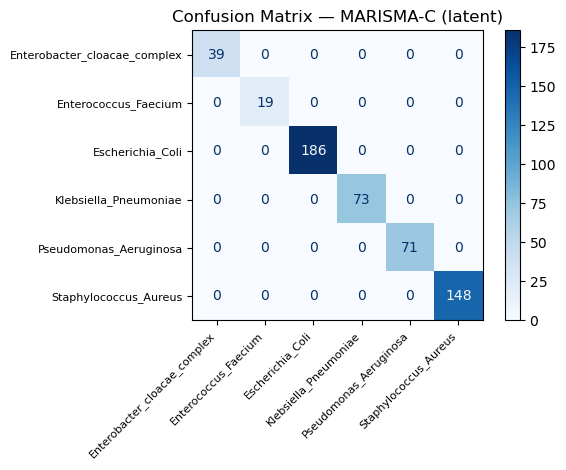


------------------------------
MARISMA to MARISMA
------------------------------

===== Metrics =====
Domain: MARISMA-MARISMA (orig)
Balanced Accuracy: 0.9930
F1 Macro: 0.9958
Recall Macro: 0.9930
Specificity Macro: 0.9996



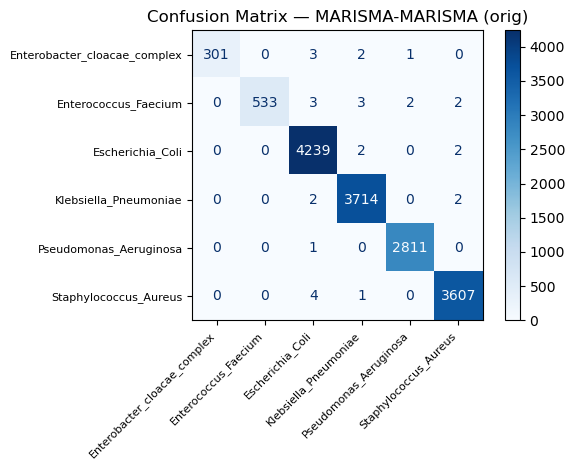


===== Metrics =====
Domain: MARISMA-MARISMA (latent)
Balanced Accuracy: 0.9948
F1 Macro: 0.9962
Recall Macro: 0.9948
Specificity Macro: 0.9996



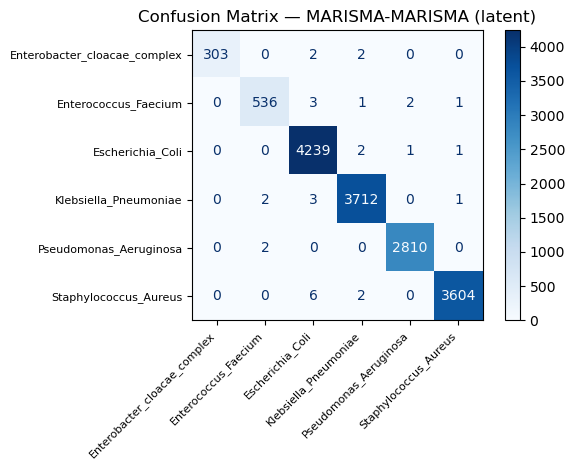


------------------------------
MARISMA to RKI
------------------------------

===== Metrics =====
Domain: MARISMA-RKI (orig)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



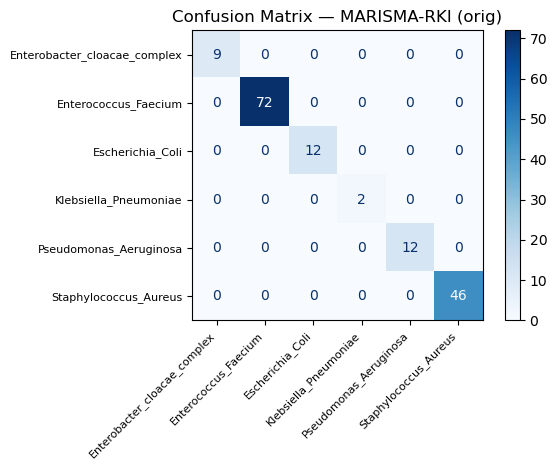


===== Metrics =====
Domain: MARISMA-RKI (latent)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



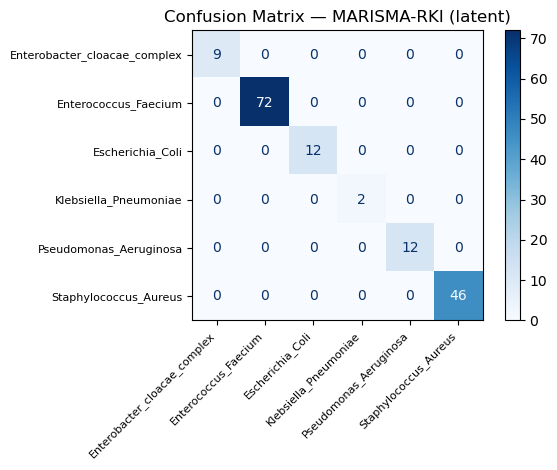


------------------------------
MARISMA to D (OOD)
------------------------------

===== Metrics =====
Domain: MARISMA-D (OOD) (orig)
Balanced Accuracy: 0.9165
F1 Macro: 0.9038
Recall Macro: 0.9165
Specificity Macro: 0.9808



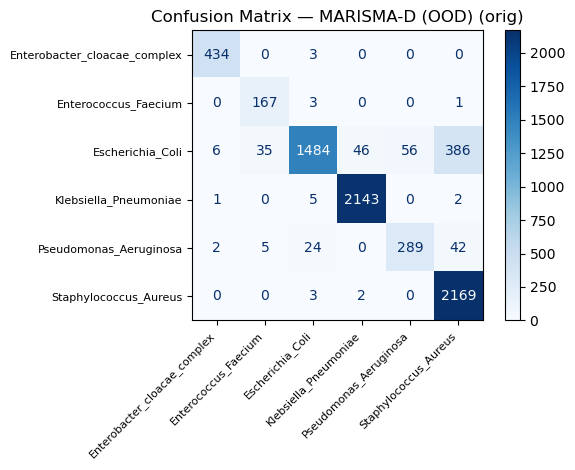


===== Metrics =====
Domain: MARISMA-D (OOD) (latent)
Balanced Accuracy: 0.9393
F1 Macro: 0.9208
Recall Macro: 0.9393
Specificity Macro: 0.9906



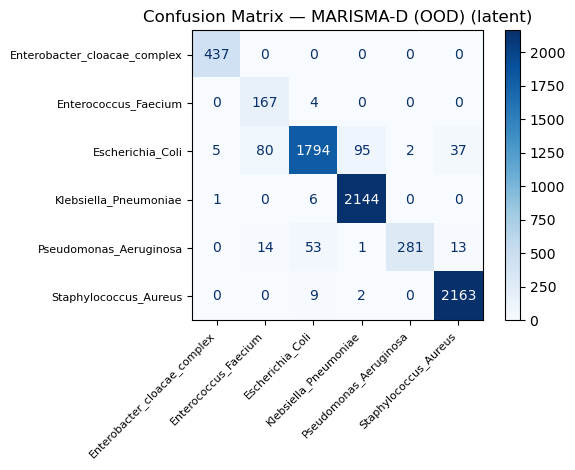


------------------------------
MARISMA to MSUMG (OOD)
------------------------------

===== Metrics =====
Domain: MARISMA-MSUMG (OOD) (orig)
Balanced Accuracy: 0.8794
F1 Macro: 0.9188
Recall Macro: 0.8794
Specificity Macro: 0.9816



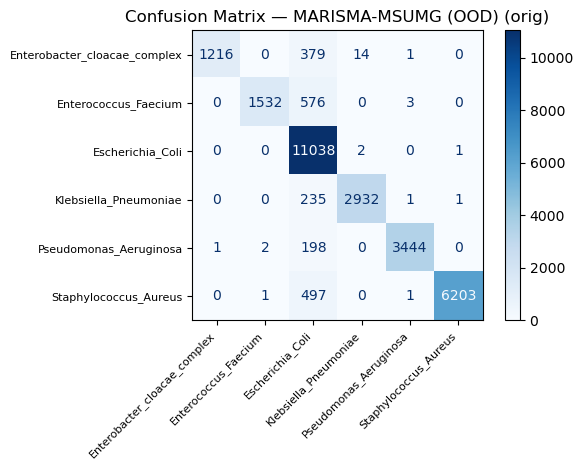


===== Metrics =====
Domain: MARISMA-MSUMG (OOD) (latent)
Balanced Accuracy: 0.9165
F1 Macro: 0.9443
Recall Macro: 0.9165
Specificity Macro: 0.9860



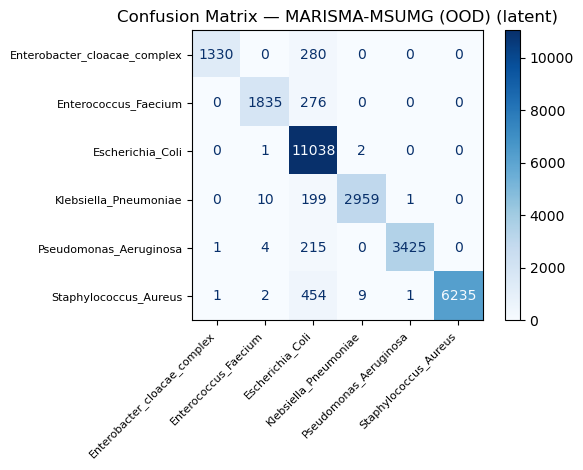


TRAIN DOMAIN: RKI

------------------------------
RKI to A
------------------------------

===== Metrics =====
Domain: RKI-A (orig)
Balanced Accuracy: 0.9897
F1 Macro: 0.9880
Recall Macro: 0.9897
Specificity Macro: 0.9980



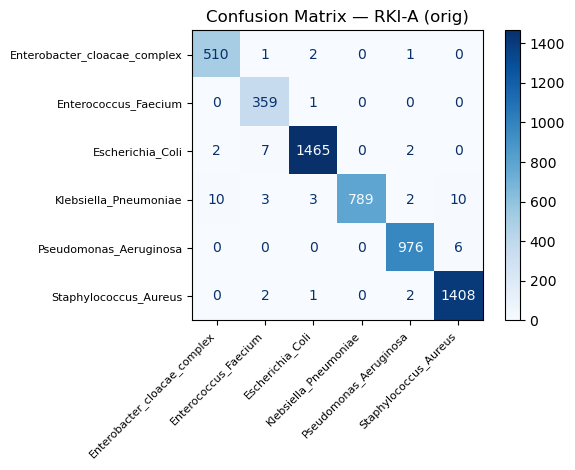


===== Metrics =====
Domain: RKI-A (latent)
Balanced Accuracy: 0.9981
F1 Macro: 0.9984
Recall Macro: 0.9981
Specificity Macro: 0.9997



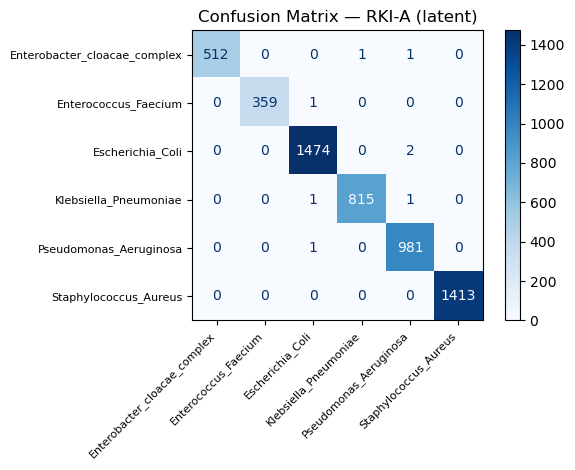


------------------------------
RKI to B
------------------------------

===== Metrics =====
Domain: RKI-B (orig)
Balanced Accuracy: 0.9902
F1 Macro: 0.9868
Recall Macro: 0.9902
Specificity Macro: 0.9986



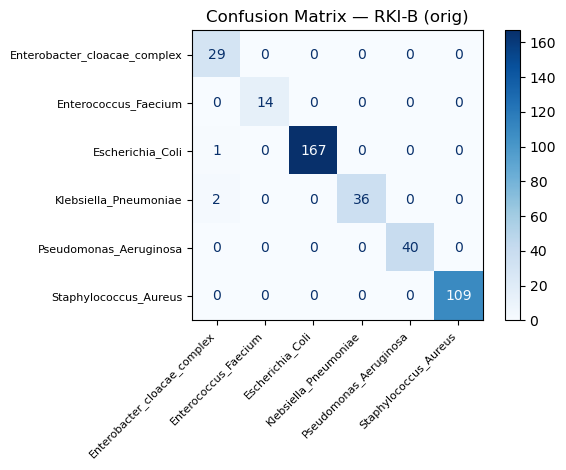


===== Metrics =====
Domain: RKI-B (latent)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



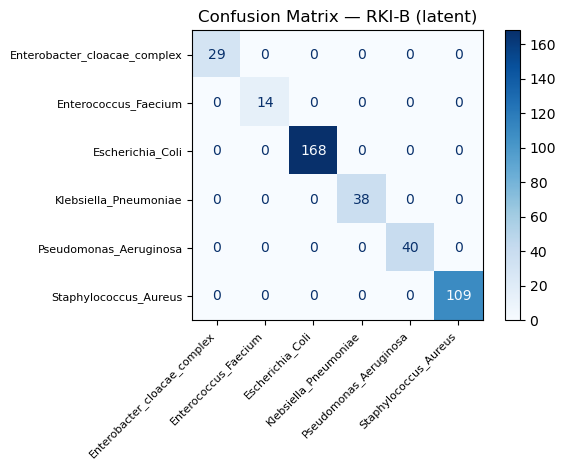


------------------------------
RKI to C
------------------------------

===== Metrics =====
Domain: RKI-C (orig)
Balanced Accuracy: 0.9950
F1 Macro: 0.9880
Recall Macro: 0.9950
Specificity Macro: 0.9985



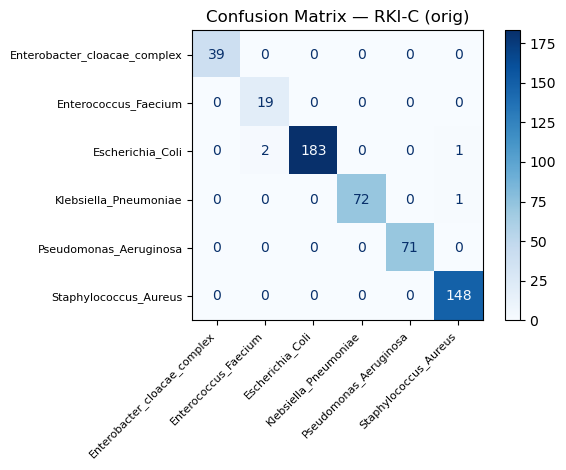


===== Metrics =====
Domain: RKI-C (latent)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



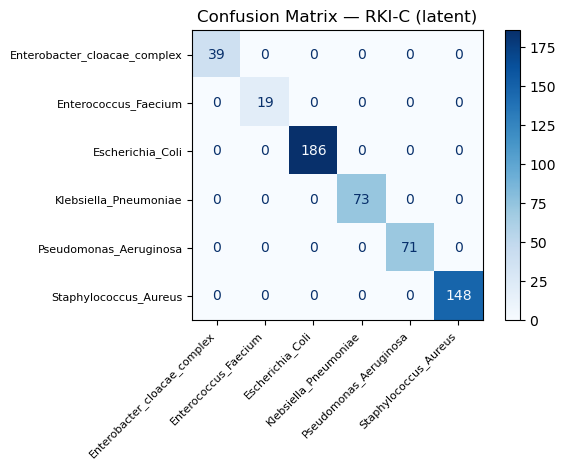


------------------------------
RKI to MARISMA
------------------------------

===== Metrics =====
Domain: RKI-MARISMA (orig)
Balanced Accuracy: 0.9610
F1 Macro: 0.9228
Recall Macro: 0.9610
Specificity Macro: 0.9936



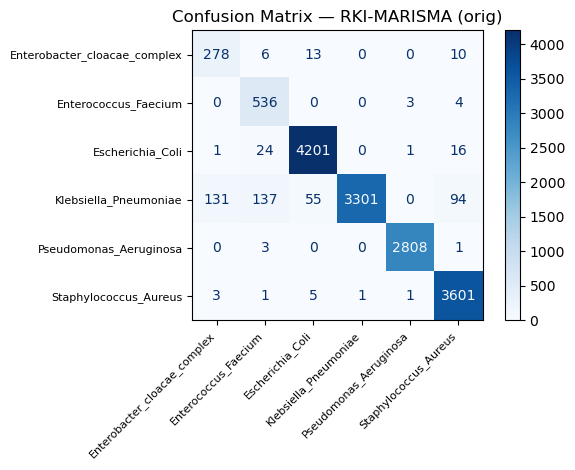


===== Metrics =====
Domain: RKI-MARISMA (latent)
Balanced Accuracy: 0.9950
F1 Macro: 0.9967
Recall Macro: 0.9950
Specificity Macro: 0.9996



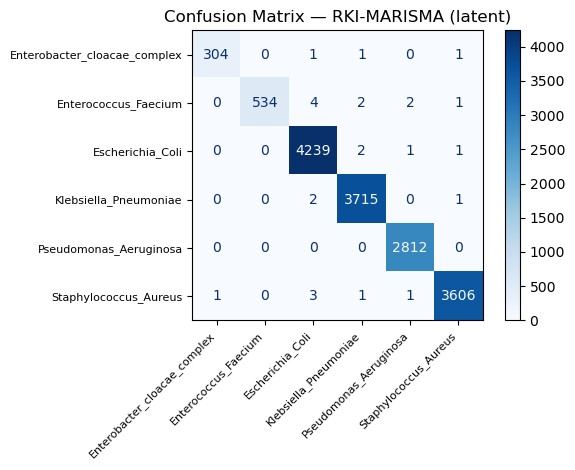


------------------------------
RKI to RKI
------------------------------

===== Metrics =====
Domain: RKI-RKI (orig)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



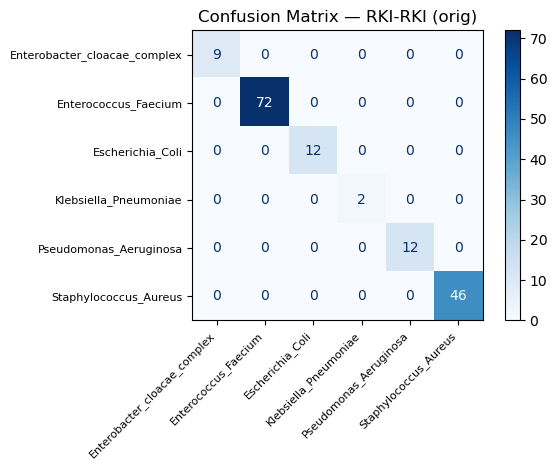


===== Metrics =====
Domain: RKI-RKI (latent)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



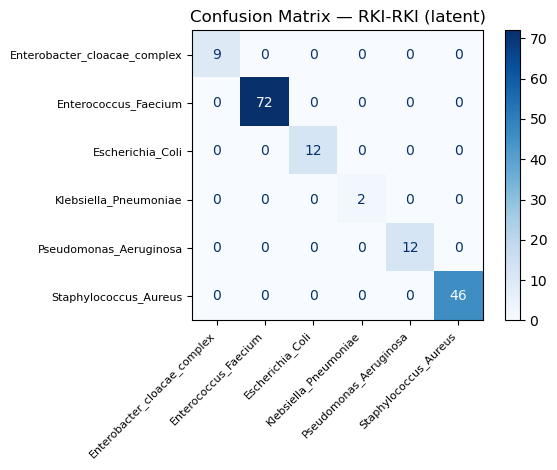


------------------------------
RKI to D (OOD)
------------------------------

===== Metrics =====
Domain: RKI-D (OOD) (orig)
Balanced Accuracy: 0.8873
F1 Macro: 0.8377
Recall Macro: 0.8873
Specificity Macro: 0.9714



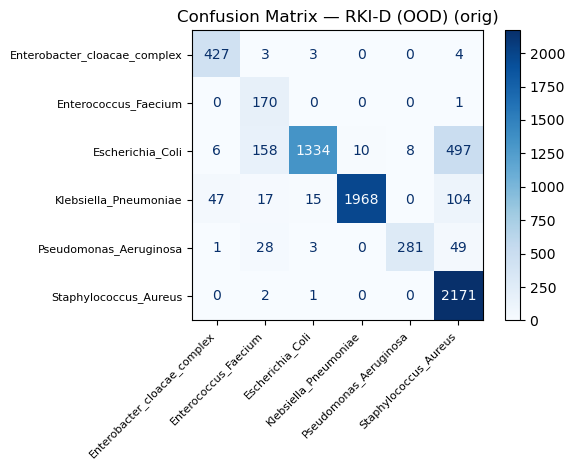


===== Metrics =====
Domain: RKI-D (OOD) (latent)
Balanced Accuracy: 0.9316
F1 Macro: 0.9229
Recall Macro: 0.9316
Specificity Macro: 0.9864



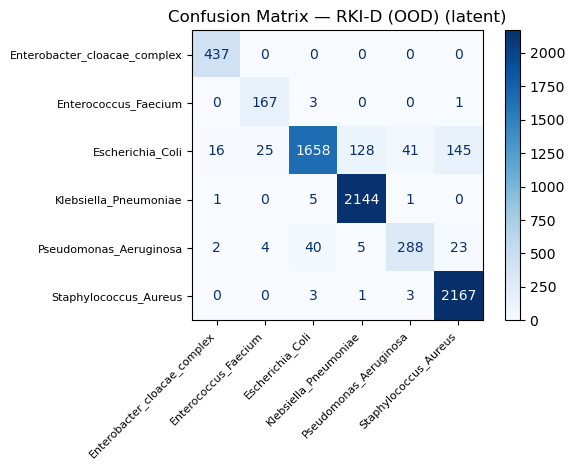


------------------------------
RKI to MSUMG (OOD)
------------------------------

===== Metrics =====
Domain: RKI-MSUMG (OOD) (orig)
Balanced Accuracy: 0.4827
F1 Macro: 0.4810
Recall Macro: 0.4827
Specificity Macro: 0.8965



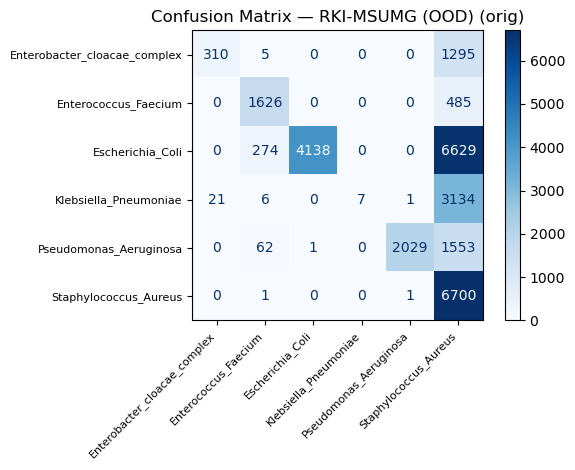


===== Metrics =====
Domain: RKI-MSUMG (OOD) (latent)
Balanced Accuracy: 0.9390
F1 Macro: 0.9601
Recall Macro: 0.9390
Specificity Macro: 0.9906



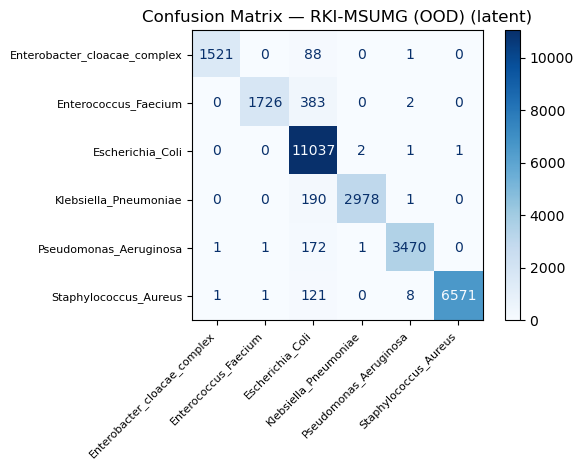

In [30]:
for train_name in domains_train.keys():
    print("\n" + "="*70)
    print(f"TRAIN DOMAIN: {train_name}")
    print("="*70)

    X_tr, y_tr = domains_train[train_name]
    Z_tr, _ = domains_train_latent[train_name]

    rf_orig = RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42
    )

    rf_lat = RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42
    )

    rf_orig.fit(X_tr, y_tr)
    rf_lat.fit(Z_tr, y_tr)

    for test_name in test_sets.keys():

        X_te, y_te = test_sets[test_name]
        Z_te, _ = test_sets_latent[test_name]

        print("\n------------------------------")
        print(f"{train_name} to {test_name}")
        print("------------------------------")

        # ORIGINAL
        metrics_orig = metrics_report(X_te, y_te, rf_orig, f"{train_name}-{test_name} (orig)")
        print_metrics(metrics_orig)

        # LATENTE
        metrics_lat = metrics_report(Z_te, y_te, rf_lat, f"{train_name}-{test_name} (latent)")
        print_metrics(metrics_lat)